# Модель для прогнозирования дефолта по кредиту клиентов банка

    
## Введение

**Бизнес-контекст и цель проекта**

  - **Бизнес-контекст** - Банк заинтересован в снижении кредитных расокв и своевременном выявлении клиентов, которые с высокой вероятностью допустят серьёзную просрочку. Ранее выявление таких клиентов позволит банку принять меры и минимизировать потери

  - **Цель работы** - Создание модели машинного обучения, способную оценить для каждого клиента банка в конкретном месяце вероятность того, что в течение ближайших 12 месяцев у него возникнет просрочка длительностью от 90 дней

**Используемые данные**

  - **Источник**: внутренние данные банка (история кредитных договоров, транзакционная активность, социальный статус, доход) и макроэкономические данные (инфляция, учетная ставка, безработица)
  - **Период**: данные охватывают период с 01/2013 по 12/2026
  - **Особенности**: данные содержат выраженный дисбаланс целевого класса (доля просрочек >90 дней существенно меньше доли «хороших» клиентов)
  
**Формализация задачи машинного обучения**

- **Объект наблюдения**: клиент банка в конкретном отчётном месяце.
- **Целевая переменная**: бинарный признак – наличие у клиента просрочки длительностью 90+ дней в ближайшие 12 месяцев (1 – просрочка была, 0 – просрочки не было).
- **Тип задачи**: бинарная классификация с учётом временной структуры данных

**План исследования**
  1. **Ознакомление с данными**
  2. **Предобработка и очистка**
  3. **Исследовательский анализ данных**
  4. **Подготовка данных к моделированию**:
   - Кодирование категориальных признаков (`OneHotEncoder`).
   - Масштабирование числовых признаков (`StandardScaler`) для линейных моделей.
   - Устранение дисбаланса классов (с помощью встроенных методов sklearn - class_weight, комбинация оверсэмплинга и андерсэмплинга).
  5. 5. **Построение моделей и обучение**:
   - Логистическая регрессия
   - Случайный лес
  6. **Сравнение и выбор лучшей модели** по ключевым метрикам
  7. **Калибровка вероятностей** выбранной модели для получения корректных оценок вероятности просрочки.
  8. **Подбор порога классификации** для достижения требуемых бизнес-метрик
  9. **Анализ матрицы ошибок** лучшей модели на тестовой и калибровочной выборках

# Структура проекта

  1. [Загрузка необходимых библиотек](#1)
  2. [Загрузка данных](#2)
  3. [Исследовательский анализ данных](#3)
  4. [Объединение таблиц](#4)
  5. [Создание новых признаков](#5)
  6. [Анализ итоговой таблицы](#6)
  7. [Моделирование](#7)
  8. [Калибровка модели и пересчёт результатов](#8)
  9. [Поиск порога решения](#9)
  10. [Анализ матрицы ошибок](#10)
  11. [Фиксирование итоговой модели](#11)
  12. [Анализ важности признаков](#12)
  13. [Выводы по проекту](#13)

<a id='1'></a>
## Загрузка необходимых библиотек

* Загрузите все библиотеки, необходимые для выполнения проекта.

In [1]:
!pip install mlxtend -q
!pip install imblearn -q
!pip install optuna -q
!pip install phik -q

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display
import random
from datetime import timedelta
from mlxtend.evaluate.time_series import (
    GroupTimeSeriesSplit,
    plot_splits,
    print_cv_info,
    print_split_info,
) 
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline 
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_auc_score, recall_score
from sklearn.metrics import precision_score, confusion_matrix, make_scorer, brier_score_loss
import optuna
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.frozen import FrozenEstimator
from sklearn.model_selection import GridSearchCV
from phik import phik

import warnings
warnings.filterwarnings('ignore', category=FutureWarning, module='sklearn.base')
warnings.filterwarnings("ignore", category=FutureWarning, module="sklearn.utils.deprecation")

In [3]:
# !pip freeze > requirements.txt

In [4]:
RANDOM_SEED = 42

<a id='2'></a>
## Загрузка данных

* Загрузите предоставленные датасеты. Обратите внимание на то, как загрузятся данные, в каком формате представлены таблицы. Пути к данным:
  * `'/datasets/ds_15_loan_payment_credit.csv'`;
  * `'/datasets/ds_15_transactions.csv'`;
  * `'/datasets/ds_15_client_description.csv'`;
  * `'/datasets/ds_15_credit_description.csv'`;
  * `'/datasets/ds_15_mortgage_presence.csv'`;
  * `'/datasets/ds_15_credit_rating.csv'`;
  * `'/datasets/ds_15_macro_data.csv'`;
  * `'/datasets/ds_15_cohort_grid.csv'`.
* Посмотрите на содержимое таблиц. Сделайте первые выводы о них.

In [5]:
loan_payment_credit = pd.read_csv('/datasets/ds_15_loan_payment_credit.csv')
transactions = pd.read_csv('/datasets/ds_15_transactions.csv')
client_description = pd.read_csv('/datasets/ds_15_client_description.csv')
credit_description = pd.read_csv('/datasets/ds_15_credit_description.csv')
mortrage_presence = pd.read_csv('/datasets/ds_15_mortgage_presence.csv')
credit_rating = pd.read_csv('/datasets/ds_15_credit_rating.csv')
macro_data = pd.read_csv('/datasets/ds_15_macro_data.csv')
cohort_grid = pd.read_csv('/datasets/ds_15_cohort_grid.csv')

In [6]:
all_tables = {
    'loan_payment_credit' : loan_payment_credit,
    'transactions' : transactions,
    'client_description' : client_description,
    'credit_description' : credit_description,
    'mortrage_presence' : mortrage_presence,
    'credit_rating' : credit_rating,
    'macro_data' : macro_data,
    'cohort_grid' : cohort_grid
}

for name, data in all_tables.items():
    print(f'Таблица {name}')
    display(data.head())
    display(data.info())
    display(data.describe())
    print('*' * 50)
    print()

Таблица loan_payment_credit


,ID,дата_начала_периода,просрочка_дней
0,IDF55109846,2014-12-01,120
1,IDF54995533,2015-06-01,121
2,IDF54964538,2018-03-01,87
3,IDF55079777,2019-09-01,109
4,IDF55093915,2017-02-01,84


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5500 entries, 0 to 5499
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID                   5500 non-null   object
 1   дата_начала_периода  5500 non-null   object
 2   просрочка_дней       5500 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 129.0+ KB


None

,просрочка_дней
count,5500.000000
mean,114.748000
std,20.362422
min,80.000000
25%,97.000000
50%,115.000000
75%,132.000000
max,150.000000


...

,ID,score_date
0,IDF55109846,2013-05-01
1,IDF55109846,2013-06-01
2,IDF55109846,2013-07-01
3,IDF55109846,2013-08-01
4,IDF55109846,2013-09-01


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577494 entries, 0 to 577493
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   ID          577494 non-null  object
 1   score_date  577494 non-null  object
dtypes: object(2)
memory usage: 8.8+ MB


None

,ID,score_date
count,577494,577494
unique,13500,84
top,IDF55024298,2019-12-01
freq,84,13500


**************************************************



Комментарии по выгруженным данным:
  - Таблица 'loan_payment_credit': 3 столбца и 5500 строк
  - Таблица 'transactions': 3 столбцов и 577_494 строк
  - Таблица 'client_description': 5 столбцов и 13500 строк
  - Таблица 'credit_description': 3 столбцов и 13500 строк
  - Таблица 'mortrage_presence': 3 столбца и 6609 строк
  - Таблица 'credit_rating': 3 столбца и 577_494 строки
  - Таблица 'macro_data': 4 столбца и 84 строки
  - Таблица 'cohort_grid': 2 стоолбца и 577_494 строки

<a id='3'></a>
## Исследовательский анализ данных

* Проведите первичный анализ данных:
    * Проверьте разные характеристики данных.
    * Исследуйте с помощью графиков количественные и категориальные данные.
    * Рекомендуем создать для этого функции, но это необязательное требование.

* Сделайте выводы о выбросах, пропусках, дубликатах и иных аномалиях в данных из каждой таблицы.

* Предобработка данных или их трансформация в этом проекте необязательны — кроме действий, необходимых для объединения таблиц.

In [7]:
# Приведение к datetime и сортировка по дате
loan_payment_credit['дата_начала_периода'] = pd.to_datetime(loan_payment_credit['дата_начала_периода']).dt.date
loan_payment_credit = loan_payment_credit.sort_values(by='дата_начала_периода')

transactions['date'] = pd.to_datetime(transactions['date']).dt.date
transactions = transactions.sort_values(by='date')

client_description['дата_регистрации'] = pd.to_datetime(client_description['дата_регистрации']).dt.date
client_description = client_description.sort_values(by='дата_регистрации')

mortrage_presence['дата_открытия'] = pd.to_datetime(mortrage_presence['дата_открытия']).dt.date
mortrage_presence = mortrage_presence.sort_values(by='дата_открытия')

credit_rating['date'] = pd.to_datetime(credit_rating['date']).dt.date
credit_rating = credit_rating.sort_values(by='date')

macro_data['date'] = pd.to_datetime(macro_data['date']).dt.date
macro_data = macro_data.sort_values(by='date')

cohort_grid['score_date'] = pd.to_datetime(cohort_grid['score_date']).dt.date
cohort_grid = cohort_grid.sort_values(by='score_date')

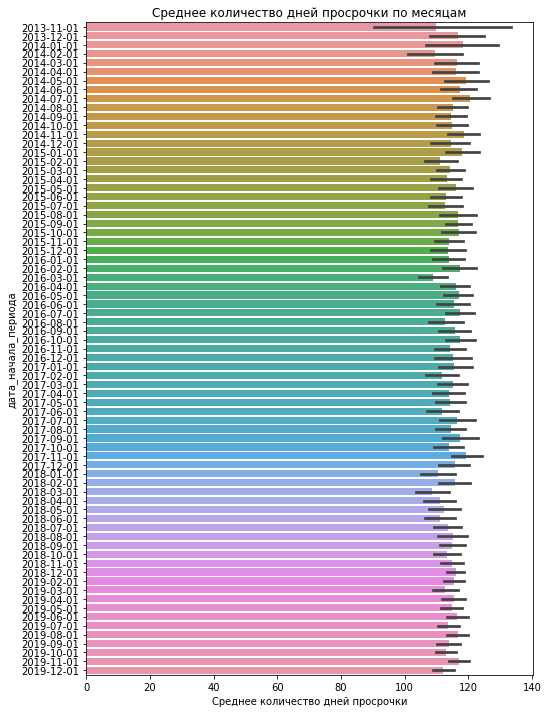

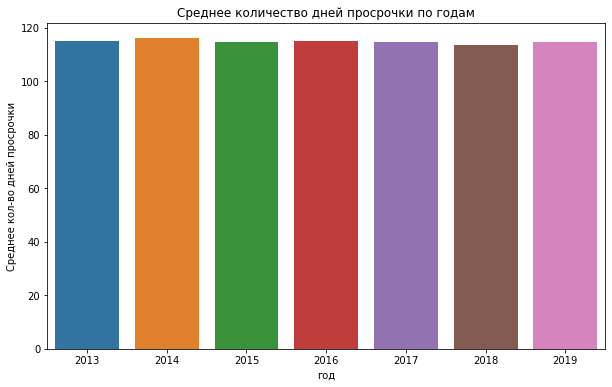

In [8]:
plt.figure(figsize=(8, 12))
sns.barplot(data=loan_payment_credit, x='просрочка_дней', y='дата_начала_периода')
plt.title('Среднее количество дней просрочки по месяцам')
plt.xlabel('Среднее количество дней просрочки')
plt.show()


loan_payment_credit_year_grouped = loan_payment_credit.copy()
loan_payment_credit_year_grouped['год'] = pd.to_datetime(loan_payment_credit_year_grouped['дата_начала_периода']).dt.year
loan_payment_credit_year_grouped = loan_payment_credit_year_grouped.groupby('год')['просрочка_дней'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(data=loan_payment_credit_year_grouped, x='год', y='просрочка_дней')
plt.title('Среднее количество дней просрочки по годам')
plt.ylabel('Среднее кол-во дней просрочки')
plt.show()

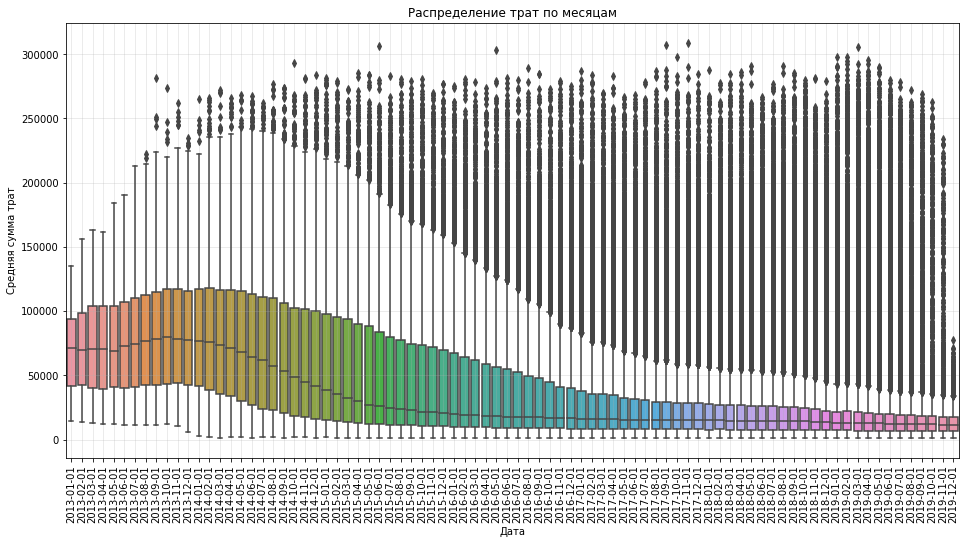

In [9]:
transactions_grouped = transactions.copy() 
transactions_grouped['общая сумма трат'] = transactions['MCC_5300'] + transactions['MCC_5814'] + transactions['MCC_5812'] + \
                                transactions['MCC_5411'] + transactions['MCC_3990'] + transactions['MCC_5722'] + \
                                transactions['MCC_4900'] + transactions['MCC_другое']

plt.figure(figsize=(16, 8))
sns.boxplot(data=transactions_grouped, x='date', y='общая сумма трат')
plt.title('Распределение трат по месяцам')
plt.xlabel('Дата')
plt.ylabel('Средняя сумма трат')
plt.xticks(rotation=90)
plt.grid(True, alpha=0.3)
plt.show()

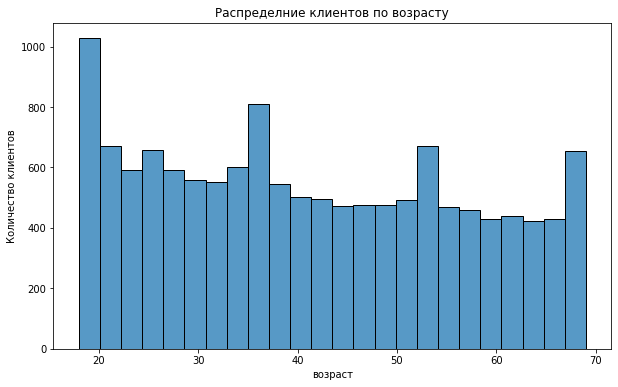

In [10]:
plt.figure(figsize=(10, 6))
sns.histplot(data=client_description, x='возраст')
plt.title('Распределние клиентов по возрасту')
plt.ylabel('Количество клиентов')
plt.show()

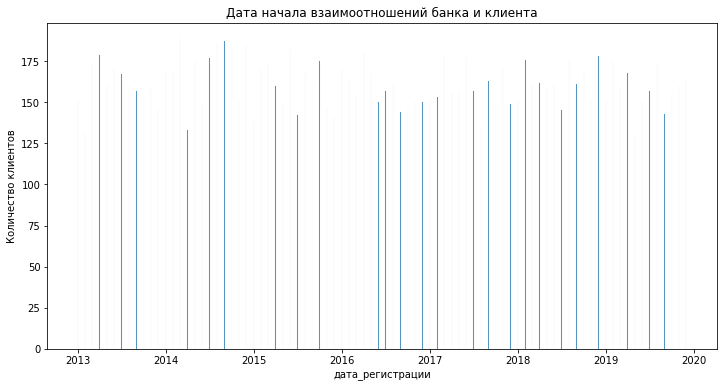

In [11]:
plt.figure(figsize=(12, 6))
sns.histplot(data=client_description, x='дата_регистрации')
plt.title('Дата начала взаимоотношений банка и клиента')
plt.ylabel('Количество клиентов')
plt.show()

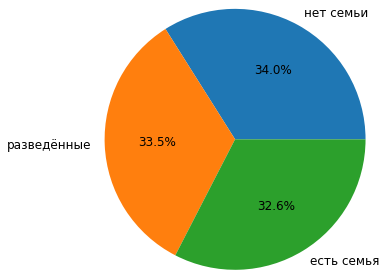

Наличие иждивенцев


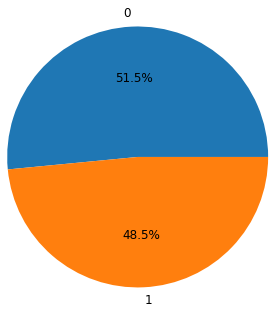

In [12]:
labels = client_description['семейное_положение'].value_counts().index
sizes = client_description['семейное_положение'].value_counts().values


fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, textprops={'size': 'large'}, autopct='%1.1f%%', radius=1.5)
plt.show()


labels = client_description['наличие_иждивенцев'].value_counts().index
sizes = client_description['наличие_иждивенцев'].value_counts().values

print('Наличие иждивенцев')
fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, textprops={'size': 'large'}, autopct='%1.1f%%', radius=1.5)
plt.show()

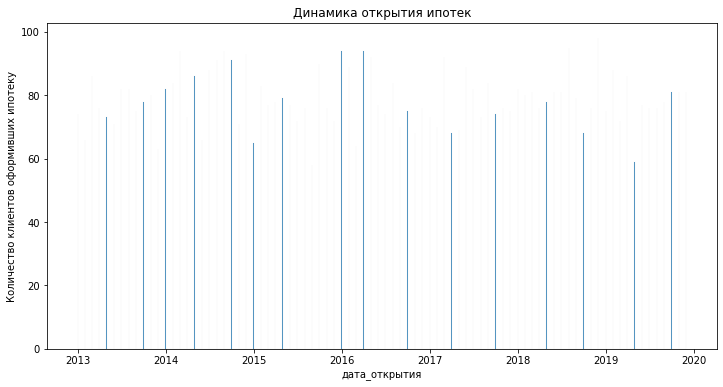

In [13]:
plt.figure(figsize=(12, 6))
sns.histplot(data=mortrage_presence, x='дата_открытия')
plt.title('Динамика открытия ипотек')
plt.ylabel('Количество клиентов оформивших ипотеку')
plt.show()

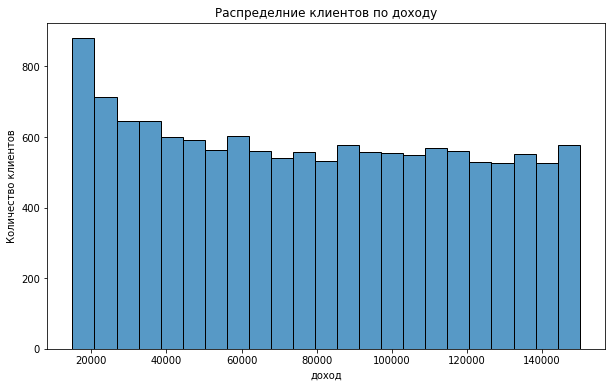

In [14]:
plt.figure(figsize=(10, 6))
sns.histplot(data=credit_description, x='доход')
plt.title('Распределние клиентов по доходу')
plt.ylabel('Количество клиентов')
plt.show()

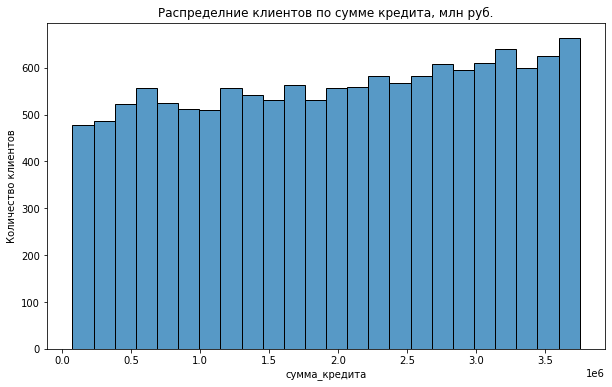

In [15]:
plt.figure(figsize=(10, 6))
sns.histplot(data=credit_description, x='сумма_кредита')
plt.title('Распределние клиентов по сумме кредита, млн руб.')
plt.ylabel('Количество клиентов')
plt.show()

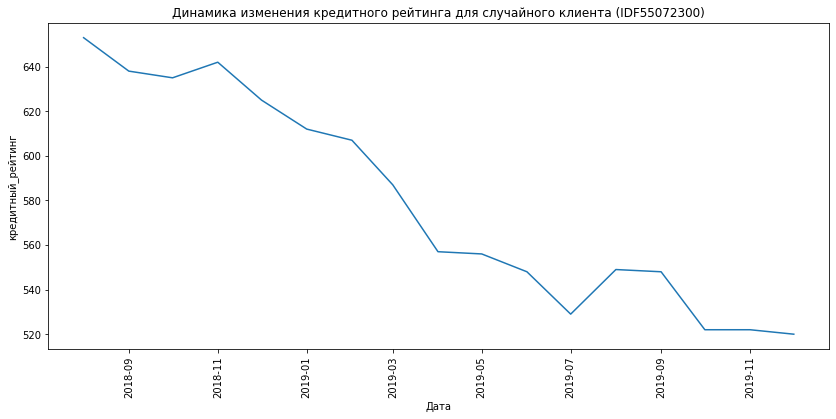

In [16]:
t = random.randint(0, credit_rating.shape[0])
random_id = credit_rating.iloc[t][0]

plot_client_rating = credit_rating[credit_rating['ID']==random_id]

plt.figure(figsize=(14, 6))
sns.lineplot(data=plot_client_rating, x='date', y='кредитный_рейтинг')
plt.title(f'Динамика изменения кредитного рейтинга для случайного клиента ({random_id})')
plt.xlabel('Дата')
plt.xticks(rotation=90)
plt.show()

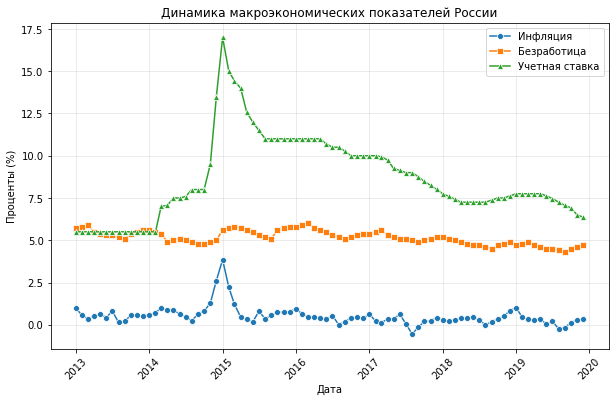

In [17]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=macro_data, x='date', y='инфляция', label='Инфляция', marker='o')
sns.lineplot(data=macro_data, x='date', y='уровень_безработицы', label='Безработица', marker='s')
sns.lineplot(data=macro_data, x='date', y='учетная_ставка', label='Учетная ставка', marker='^')

plt.title('Динамика макроэкономических показателей России')
plt.xlabel('Дата')
plt.ylabel('Проценты (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()

In [18]:
for name, table in all_tables.items():
    print(f'Количество дубликатов в таблице {name}')
    print(table.duplicated().sum())
    print()

Количество дубликатов в таблице loan_payment_credit
0

Количество дубликатов в таблице transactions
0

Количество дубликатов в таблице client_description
0

Количество дубликатов в таблице credit_description
0

Количество дубликатов в таблице mortrage_presence
0

Количество дубликатов в таблице credit_rating
0

Количество дубликатов в таблице macro_data
0

Количество дубликатов в таблице cohort_grid
0



    Выводы:
      - Среднее количество дней просрочки остается стабильным во времени и обычно не превышает 120 дней
      - С течением времени средние общие траты снижаются, при этом количество выбросов "вверх" увеличивается. За весь период медианные общие траты упали с ~68 тысяч рублей в начале 2013 года до ~13 тысяч рублей к концу 2019
      - Множество клиентов приходится на возврастной сегмент "до 20 лет". С увеличением возраста количество клиентов немного снижается
      - Начало взимоотношений клиента и банка стабильно приходятся на 3-4 месяца в году
      - Семейное положение клиентов распределено почти что равномерно между "разведен(а)" (33,5%), "есть семья" (32,6%), "нет семьи" (34%)
      - У 48,5% клиентов есть иждивенцы
      - Открытия ипотек стабильно приходятся на 2-3 месяца в году
      - Множество клиентов имеют доход до 40 тыс руб., при этом наибольшее количество клиентов имеют доход до 20 тыс руб. Остальные клиенты имеют доход от 40 тыс до ~150 тыс руб., при этом распределение количества клиентов в этом диапазоне почти равномерно
      - Чем больше сумма кредита, тем больше количество клиентов
      - Для большей части случайно выбранных клиентов кредитный рейтинг снижается со временем
      - На протяжении всего времени безработица очень медленно снижается, но по итогу остается вблизи 5%. 
      - До 2014 года учетная ставка была на уровне 5%, в 2014 году наблюдается резкий скачок до 17% и с того времени идет тенденция на снижение - к 2020 году учетная ставка составляет 6,4%
      - Инфляция остается примерно на одном уровне в течение всего срока, за исключением периода со второй половины 2014 до конца 1 квартала 2015 года, когда инфляция резко выросла до ~4%
      - Ни в одной таблице не выявлено полных дубликатов в данных
      - Аномальных выбросов, требующих дополнительной обработки не найдено

<a id='4'></a>
## Объединение таблиц

Соберите все источники данных о клиентах в единую таблицу наблюдений.

### Формирование целевой переменной

1. Значение бинарной целевой переменной нужно определить для каждой строки со столбцами `ID` и `score_date` в таблице `cohort_grid`.

2. Таргет равен 1 при соблюдении двух условий:
    * Если значение в поле `просрочка_дней` больше или равно 90.
    * Если для клиента существует строка в таблице `loan_payment_credit`, где значение в поле `дата_начала_периода` попадает в интервал `[score_date, score_date + 365 дней)`.

>Важно: у клиента может быть несколько эпизодов с просрочками от 90 дней. Вам нужно взять первый по времени возникновения эпизод в таблице с просрочками.

3. После расчёта целевой переменной удалите строки, где дефолт уже произошёл к моменту скоринга, то есть `дата_начала_периода < score_date`. Это необходимо, так как для корректной работы с временной структурой важно учитывать дефолты, произошедшие в прошлом относительно даты скоринга.

### Создание итоговой таблицы

1. В качестве признаков можно использовать только информацию о прошлом, то есть она должна быть доступна к дате скоринга. Иными словами, в каждой строке нужно присоединить данные о поведении клиента за предыдущие периоды относительно даты скоринга, иначе произойдёт утечка данных из будущего.

>К примеру, `score_date = 2024-01-15`. Тогда:
>* транзакции за декабрь 2023 г. — можем использовать;
>* транзакции за ноябрь 2023 г. — можем использовать;
>* транзакции 16 января 2024 г. — **не** можем использовать.

2. Присоедините остальные данные по клиенту, помимо указанных выше данных о макроэкономике и транзакциях клиента.

> Рекомендации:
>* Не забывайте проверять правильность каждого этапа сбора данных в единую таблицу. Это можно отслеживать на одном из клиентов.
>* При формировании таблицы следите за тем, чтобы в ней была корректно проведена работа со временем:
  >   * Отследите, не упущены ли какие-то данные из прошлого;
  >   * Проконтролируйте, верно ли рассчитана целевая переменная, которая зависит от дефолта в будущем.
>* Помните, что даты в исходных таблицах указаны на первое число месяца. Учитывайте период, который они описывают.

Сделайте выводы о получившейся таблице.

In [19]:
df = cohort_grid.merge(loan_payment_credit, on='ID', how='left')
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 577494 entries, 0 to 577493
Data columns (total 4 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   ID                   577494 non-null  object 
 1   score_date           577494 non-null  object 
 2   дата_начала_периода  234907 non-null  object 
 3   просрочка_дней       234907 non-null  float64
dtypes: float64(1), object(3)
memory usage: 22.0+ MB


In [20]:
# Преобразование в datetime
df['дата_начала_периода'] = pd.to_datetime(df['дата_начала_периода'])
df['score_date'] = pd.to_datetime(df['score_date'])

In [21]:
df['target'] = np.where((df['просрочка_дней']>=90) &
                        (df['дата_начала_периода'] >= df['score_date']) &
                        (df['дата_начала_периода'] < df['score_date'] + pd.DateOffset(days=365)), 1, 0)

In [22]:
df['дата_начала_периода'] = df['дата_начала_периода'].fillna(df['дата_начала_периода'].max())
df['просрочка_дней'] = df['просрочка_дней'].fillna(0)

In [23]:
df_filtred = df[(df['дата_начала_периода'] >= df['score_date'])]

In [24]:
# Убираем данные, где разница между 'дата_начала_периода' и 'score_date' меньше 12 месяцев
max_start_period = df_filtred['дата_начала_периода'].max()
df_filtred = df_filtred[(df_filtred['score_date'] <= max_start_period - pd.DateOffset(days=365))]

In [25]:
df_filtred['score_date'] = pd.to_datetime(df_filtred['score_date'])
transactions['date'] = pd.to_datetime(transactions['date'])
credit_rating['date'] = pd.to_datetime(credit_rating['date'])
macro_data['date'] = pd.to_datetime(macro_data['date'])

df_filtred = df_filtred.sort_values(['score_date', 'ID'])
transactions = transactions.sort_values(['date', 'ID'])

# Объединение таблиц
data = pd.merge_asof(
    df_filtred,
    transactions,
    left_on='score_date',
    right_on='date',
    by='ID',
    direction='backward',
    allow_exact_matches=False
)

                                             
data = data.merge(client_description, on='ID', how='left')


data = data.merge(mortrage_presence, on='ID', how='left')
data['наличие_ипотеки'] = data['наличие_ипотеки'].fillna(0)


data = data.merge(credit_rating, left_on=['ID', 'score_date'],
                       right_on=['ID', 'date'], how='left')


data = data.merge(macro_data, left_on='score_date', right_on='date', how='left')

data = data.merge(credit_description, on='ID', how='left')

data = data.sort_values(by='score_date')
data

,ID,score_date,дата_начала_периода,просрочка_дней,target,date_x,MCC_5300,MCC_5814,MCC_5812,MCC_5411,...,дата_открытия,наличие_ипотеки,date_y,кредитный_рейтинг,date,учетная_ставка,уровень_безработицы,инфляция,доход,сумма_кредита
0,IDF54897139,2013-01-01,2013-11-01,144.0,1,NaT,NaN,NaN,NaN,NaN,...,2013-01-01,1.0,2013-01-01,665,2013-01-01,5.500,5.7,0.97,88630,3174630
97,IDF55060576,2013-01-01,2014-03-01,135.0,0,NaT,NaN,NaN,NaN,NaN,...,NaN,0.0,2013-01-01,784,2013-01-01,5.500,5.7,0.97,143372,1269390
98,IDF55061078,2013-01-01,2014-09-01,102.0,0,NaT,NaN,NaN,NaN,NaN,...,NaN,0.0,2013-01-01,691,2013-01-01,5.500,5.7,0.97,126588,1598085
99,IDF55061465,2013-01-01,2019-12-01,0.0,0,NaT,NaN,NaN,NaN,NaN,...,2013-01-01,1.0,2013-01-01,720,2013-01-01,5.500,5.7,0.97,56695,2833995
100,IDF55061567,2013-01-01,2019-12-01,0.0,0,NaT,NaN,NaN,NaN,NaN,...,NaN,0.0,2013-01-01,729,2013-01-01,5.500,5.7,0.97,26417,2085105
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314390,IDF54981909,2018-12-01,2019-12-01,0.0,0,2018-11-01,2243.05,383.84,1397.41,2596.35,...,NaN,0.0,2018-12-01,446,2018-12-01,7.625,4.9,0.84,88259,3595815
314389,IDF54981821,2018-12-01,2019-12-01,0.0,0,2018-11-01,1556.97,615.60,636.08,3022.97,...,2013-12-01,1.0,2018-12-01,547,2018-12-01,7.625,4.9,0.84,118171,2730390
314388,IDF54981814,2018-12-01,2019-12-01,0.0,0,2018-11-01,2282.95,1871.18,1420.18,5335.80,...,NaN,0.0,2018-12-01,569,2018-12-01,7.625,4.9,0.84,131634,2839215
314416,IDF54982764,2018-12-01,2019-12-01,0.0,0,2018-11-01,1828.79,558.30,629.67,2501.42,...,NaN,0.0,2018-12-01,599,2018-12-01,7.625,4.9,0.84,104982,559815


In [26]:
# удаляем ненужные столбцы
data = data.drop(columns=['дата_начала_периода', 'date_x', 'date_y',
                          'дата_регистрации', 'дата_открытия', 'date', 'просрочка_дней'])

# Удаляем пустые значения
data = data.dropna()

In [27]:
data

,ID,score_date,target,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,...,возраст,семейное_положение,наличие_иждивенцев,наличие_ипотеки,кредитный_рейтинг,учетная_ставка,уровень_безработицы,инфляция,доход,сумма_кредита
333,IDF55059710,2013-02-01,1,9328.91,3449.16,4060.47,14697.06,1769.77,5772.71,11718.64,...,33,разведённые,0,1.0,636,5.500,5.8,0.56,69734,3676065
345,IDF55078056,2013-02-01,0,5067.16,1908.93,1934.04,9032.03,951.65,3275.86,6318.04,...,21,есть семья,1,1.0,739,5.500,5.8,0.56,43440,3043245
343,IDF55076663,2013-02-01,0,7768.73,2954.43,2805.92,13305.14,1447.66,5323.50,8906.49,...,24,разведённые,0,1.0,759,5.500,5.8,0.56,60202,404220
342,IDF55071007,2013-02-01,0,11125.47,4299.55,4811.70,20084.08,2470.83,8398.98,15330.61,...,68,есть семья,0,1.0,681,5.500,5.8,0.56,96246,658560
341,IDF55065384,2013-02-01,0,16698.19,6765.33,6843.62,29883.13,3267.12,9819.50,20500.14,...,19,есть семья,1,0.0,620,5.500,5.8,0.56,127124,2058750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314390,IDF54981909,2018-12-01,0,2243.05,383.84,1397.41,2596.35,204.15,688.37,535.28,...,26,нет семьи,1,0.0,446,7.625,4.9,0.84,88259,3595815
314389,IDF54981821,2018-12-01,0,1556.97,615.60,636.08,3022.97,355.62,2251.48,916.43,...,60,разведённые,0,1.0,547,7.625,4.9,0.84,118171,2730390
314388,IDF54981814,2018-12-01,0,2282.95,1871.18,1420.18,5335.80,452.98,1489.10,1174.77,...,58,нет семьи,0,0.0,569,7.625,4.9,0.84,131634,2839215
314416,IDF54982764,2018-12-01,0,1828.79,558.30,629.67,2501.42,283.98,1706.36,729.11,...,37,разведённые,0,0.0,599,7.625,4.9,0.84,104982,559815


In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 307963 entries, 333 to 319575
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   ID                   307963 non-null  object        
 1   score_date           307963 non-null  datetime64[ns]
 2   target               307963 non-null  int64         
 3   MCC_5300             307963 non-null  float64       
 4   MCC_5814             307963 non-null  float64       
 5   MCC_5812             307963 non-null  float64       
 6   MCC_5411             307963 non-null  float64       
 7   MCC_3990             307963 non-null  float64       
 8   MCC_5722             307963 non-null  float64       
 9   MCC_4900             307963 non-null  float64       
 10  MCC_другое           307963 non-null  float64       
 11  возраст              307963 non-null  int64         
 12  семейное_положение   307963 non-null  object        
 13  наличие_ижди


    В результате объединения таблиц, формирования целевой переменной и последующего удаления пустых значений количество строк в датафрейме сократилось с 577_494 в изначальном до 307_963 в итоговом, т.е. было удалено 46,7% записей. Несмотря на это, у нас остается достаточно наблюдений для создания модели, прогнозирующей вероятность дефолта.

<a id='5'></a>
## Создание новых признаков

* Добавьте в таблицу новые признаки, которые помогли бы описать поведение клиента. Создайте не менее двух новых признаков.
* Сделайте выводы о новых признаках.

In [29]:
# Сумма транзакций, приходящаяся на единицу рейтинга
data['tranc_per_rating'] = data[['MCC_5300', 'MCC_5814', 'MCC_5812',
                                 'MCC_5411', 'MCC_3990', 'MCC_5722',
                                 'MCC_4900', 'MCC_другое']].sum(axis=1) / data['кредитный_рейтинг']

# признак, учитывающий 'отягчающие' для платы факторы (корень взят чтобы сгладить значения)
data['aggravating_coef'] = np.sqrt(data['возраст'] * (1 + data['наличие_иждивенцев'] + data['наличие_ипотеки']))

# отношение доходов к тратам
data['income/spending'] = data['доход'] / data[['MCC_5300', 'MCC_5814', 'MCC_5812',
                                                'MCC_5411', 'MCC_3990', 'MCC_5722',
                                                'MCC_4900', 'MCC_другое']].sum(axis=1)

# отношение суммы кредита к доходам
data['credit load'] = data['сумма_кредита'] / data['доход']

    Описание логики:
    - Сумма транзакций, приходящаяся на единицу рейтинга - этот коэффициент позволяет точнее рассчитать располагаемый доход
    - Признак, учитывающий 'отягчающие' для платы факторы - наличие иждивенцец и наличие ипотеки требуют дополнительные расходы, что увеличивает банковские риски
    - Отношение доходов к тратам - позволяет отслеживать "финансовое поведение" клиента и его остаток свободных средств для выплаты кредита
    - Отношение суммы кредита к доходам - позволяет банку отследить "финансовую нагрузку" на клиента от кредита

<a id='6'></a>
## Анализ итоговой таблицы

* Проведите краткий анализ получившейся итоговой таблицы.
* Сделайте вывод о данных для моделирования.
* Проверьте целевую переменную на предмет дисбаланса классов. Сделайте выводы.

In [30]:
data

,ID,score_date,target,MCC_5300,MCC_5814,MCC_5812,MCC_5411,MCC_3990,MCC_5722,MCC_4900,...,кредитный_рейтинг,учетная_ставка,уровень_безработицы,инфляция,доход,сумма_кредита,tranc_per_rating,aggravating_coef,income/spending,credit load
333,IDF55059710,2013-02-01,1,9328.91,3449.16,4060.47,14697.06,1769.77,5772.71,11718.64,...,636,5.500,5.8,0.56,69734,3676065,95.176289,8.124038,1.152016,52.715533
345,IDF55078056,2013-02-01,0,5067.16,1908.93,1934.04,9032.03,951.65,3275.86,6318.04,...,739,5.500,5.8,0.56,43440,3043245,45.474899,7.937254,1.292628,70.056285
343,IDF55076663,2013-02-01,0,7768.73,2954.43,2805.92,13305.14,1447.66,5323.50,8906.49,...,759,5.500,5.8,0.56,60202,404220,66.594032,6.928203,1.191061,6.714395
342,IDF55071007,2013-02-01,0,11125.47,4299.55,4811.70,20084.08,2470.83,8398.98,15330.61,...,681,5.500,5.8,0.56,96246,658560,115.953040,11.661904,1.218859,6.842466
341,IDF55065384,2013-02-01,0,16698.19,6765.33,6843.62,29883.13,3267.12,9819.50,20500.14,...,620,5.500,5.8,0.56,127124,2058750,180.271371,6.164414,1.137389,16.194818
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
314390,IDF54981909,2018-12-01,0,2243.05,383.84,1397.41,2596.35,204.15,688.37,535.28,...,446,7.625,4.9,0.84,88259,3595815,20.766928,7.211103,9.529100,40.741624
314389,IDF54981821,2018-12-01,0,1556.97,615.60,636.08,3022.97,355.62,2251.48,916.43,...,547,7.625,4.9,0.84,118171,2730390,20.302102,10.954451,10.641003,23.105415
314388,IDF54981814,2018-12-01,0,2282.95,1871.18,1420.18,5335.80,452.98,1489.10,1174.77,...,569,7.625,4.9,0.84,131634,2839215,30.622460,7.615773,7.554674,21.569010
314416,IDF54982764,2018-12-01,0,1828.79,558.30,629.67,2501.42,283.98,1706.36,729.11,...,599,7.625,4.9,0.84,104982,559815,16.383289,6.082763,10.697614,5.332486


In [31]:
print(f"Количетво дубликатов по столбцам ID и score_date: {data.duplicated(subset=['ID', 'score_date']).sum()}")

Количетво дубликатов по столбцам ID и score_date: 0


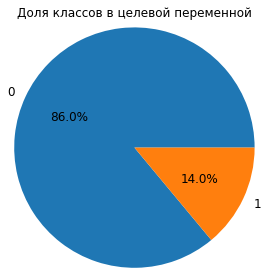

In [32]:
labels = data['target'].value_counts().index
sizes = data['target'].value_counts().values


fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, textprops={'size': 'large'}, autopct='%1.1f%%', radius=1.2)
plt.title('Доля классов в целевой переменной')
plt.tight_layout()
plt.show()


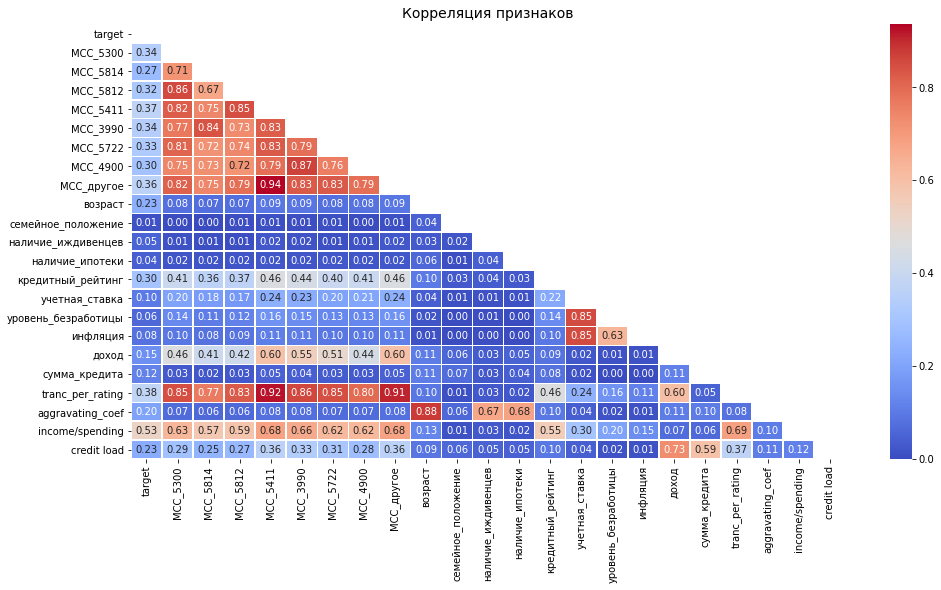

In [33]:
# Корреляция

interval_cols = ['target', 'MCC_5300', 'MCC_5814',
                 'MCC_5812', 'MCC_5411', 'MCC_3990', 'MCC_5722',
                 'MCC_4900', 'MCC_другое', 'возраст', 'наличие_иждивенцев',
                 'наличие_ипотеки', 'кредитный_рейтинг', 'учетная_ставка',
                 'уровень_безработицы', 'инфляция', 'доход', 'сумма_кредита',
                 'tranc_per_rating', 'aggravating_coef',
                 'income/spending', 'credit load']

corr_data = data.drop(columns=['ID', 'score_date']).phik_matrix(interval_cols=interval_cols)

plt.figure(figsize=(16, 8))
mask = np.triu(np.ones_like(corr_data, dtype=bool))
sns.heatmap(data=corr_data, annot=True,
            fmt='.2f', linewidths=0.5,
            cmap='coolwarm', mask=mask,)
plt.title('Корреляция признаков', fontsize=14)
plt.show()

    Выводы по данным:
    - В целевой переменной наблюдается дисбаланс классов - на положительный класс приходится 14% наблюдений, на отрицательный - 86%
    - Для устранения дисбаланса будет в моделях будут применяться встроенный в sklearn параметр class_weight и стратегии комбинированного овер и андерсэмплинга
    - При анализе корреляции наиболее явно выделяется высокая корреляция между признаками, отвечающими за сумму транзакций в различных категориях
    - Признаки "наличие ипотеки", "семейное положение", "наличие иждивенцев", "инфляция", "уровень безработицы", "учетная ставка" не имеют хоть немного выраженной корреляции с целевой переменной
    - Наибольшая корреляция с целевой переменой (0.53) наблюдается у признака, отображающего отношение доходов к тратам (income/spending)

<a id='7'></a>
## Моделирование

### Базовые модели

1. Подготовьте обучающую, калибровочную и тестовую выборки. Разбейте обучающую на три фолда для последующего использования кросс-валидации. Для оценки качества и калибровки используйте размер выборки, равный 12 месяцам.


2. При необходимости проведите категоризацию данных, применив нужный Encoder и использовав пайплайн.

3. Обучите базовые модели с кросс-валидацией по трём фолдам:
    * Две базовые модели — логистическую регрессию и случайный лес — без балансировки классов в целевой переменной.
    * Логистическую регрессию и случайный лес с балансировкой классов. Выберите метод балансировки самостоятельно. Обязательно примените хотя бы один метод. Можно попробовать несколько и выбрать лучший.
    * Сделайте выводы о работе всех четырёх моделей.

4. Случайный лес с настройками по умолчанию легко переобучается, потому что запоминает обучающую выборку, из-за чего модель может терять в качестве на новых данных. Логистическая регрессия же сразу готова к работе за счёт встроенной L2-регуляризации, которая автоматически контролирует сложность модели.

   Чтобы исправить проблемы модели Random Forest, вам нужно подобрать для неё гиперпараметры с помощью  Optuna. Количество гиперпараметров должно быть не менее трёх. Для оптимизации используйте метрику missed defaults rate.

5. Сравните все полученные модели.

6. Для оценки моделей используйте метрики:
   * accuracy или ROC-AUC,
   * approval rate,
   * default rate,
   * missed defaults rate.

7. Сделайте вывод о работе, проделанной в этом разделе.

In [34]:
data = data.sort_values(['ID', 'score_date'])

data['lag_1_target'] = data.groupby('ID')['target'].shift(1)

data = data.dropna(subset=['lag_1_target'])

# Удаляем столбец
data = data.drop(columns='target')

max_date = data['score_date'].max()
cal_start = max_date - pd.DateOffset(months=24)
test_start = max_date - pd.DateOffset(months=12)

df_train = data[data['score_date'] < cal_start].copy()
df_calib = data[(data['score_date'] >= cal_start) & (data['score_date'] < test_start)].copy()
df_test  = data[data['score_date'] >= test_start].copy()

train_ids = set(df_train['ID'])
calib_ids = set(df_calib['ID'])
test_ids = set(df_test['ID'])

print(f"Клиентов в трейне: {len(train_ids)}")
print(f"Из них перешло в калибровку: {len(train_ids & calib_ids)}")
print(f"Из них перешло в тест: {len(train_ids & test_ids)}")
print()
print(f"Тренировочная выборка: {df_train['score_date'].min().date()} - {df_train['score_date'].max().date()} | Строк: {len(df_train)}")
print(f"Калибровочная выборка: {df_calib['score_date'].min().date()} - {df_calib['score_date'].max().date()} | Строк: {len(df_calib)}")
print(f"Тестовая выборка:  {df_test['score_date'].min().date()} - {df_test['score_date'].max().date()} | Строк: {len(df_test)}")

Клиентов в трейне: 7321
Из них перешло в калибровку: 5192
Из них перешло в тест: 4488

Тренировочная выборка: 2013-03-01 - 2016-11-01 | Строк: 135169
Калибровочная выборка: 2016-12-01 - 2017-11-01 | Строк: 70240
Тестовая выборка:  2017-12-01 - 2018-12-01 | Строк: 91119


In [35]:
t = ['семейное_положение', 'ID', 'score_date', 'lag_1_target']
num_features = list(set(data.columns) - set(t))

In [36]:
logreg_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('categ', OneHotEncoder(drop='first', handle_unknown='ignore',
                                sparse_output=False), ['семейное_положение'])
    ]
)

rf_preprocessor = ColumnTransformer(
    transformers=[
        ('categ', OneHotEncoder(drop='first', handle_unknown='ignore',
                                sparse_output=False), ['семейное_положение']),
        ('other', 'passthrough', num_features)
    ]
)

In [37]:
pipelines = {
    'logistic_regression_base': Pipeline([
        ('prep', logreg_preprocessor),
        ('model', LogisticRegression(random_state=RANDOM_SEED))
    ]),
    
    'logistic_regression_over_under': ImbPipeline([
        ('prep', logreg_preprocessor),
        ('over', RandomOverSampler(random_state=RANDOM_SEED, sampling_strategy=0.3)),
        ('under', RandomUnderSampler(random_state=RANDOM_SEED, sampling_strategy=0.6)),
        ('model', LogisticRegression(random_state=RANDOM_SEED))
    ]),

    'logistic_regression_balanced': Pipeline([
        ('prep', logreg_preprocessor),
        ('model', LogisticRegression(random_state=RANDOM_SEED, class_weight='balanced'))
    ]),
    
    'rf_base': Pipeline([
        ('prep', rf_preprocessor),
        ('model', RandomForestClassifier(random_state=RANDOM_SEED))
    ]),
    
    'rf_over_under': ImbPipeline([
        ('prep', rf_preprocessor),
        ('over', RandomOverSampler(random_state=RANDOM_SEED, sampling_strategy=0.3)),
        ('under', RandomUnderSampler(random_state=RANDOM_SEED, sampling_strategy=0.6)),
        ('model', RandomForestClassifier(random_state=RANDOM_SEED))
    ]),
    
    'rf_balanced': Pipeline([
        ('prep', rf_preprocessor),
        ('model', RandomForestClassifier(random_state=RANDOM_SEED, class_weight='balanced'))
    ])
}

In [38]:
df_train = df_train.sort_values(by='score_date')

In [39]:
X_train = df_train.copy()
X_train.index = X_train['score_date'].rank(method='dense').astype(int)

X_train = X_train.drop(columns=['score_date', 'ID', 'lag_1_target'])
y_train = df_train['lag_1_target']

groups = X_train.index

In [40]:
def get_missed_defaults_rate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn / (fn + tp)

In [41]:
missed_defaults_scorer = make_scorer(
    get_missed_defaults_rate,
    greater_is_better=False
)

In [42]:
cv_args = {"n_splits": 3, "test_size":3, 'window_type':'expanding'}

gtscv = GroupTimeSeriesSplit(**cv_args)

/opt/conda/lib/python3.9/site-packages/mlxtend/evaluate/time_series.py:335: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations. 
  plt.tight_layout()


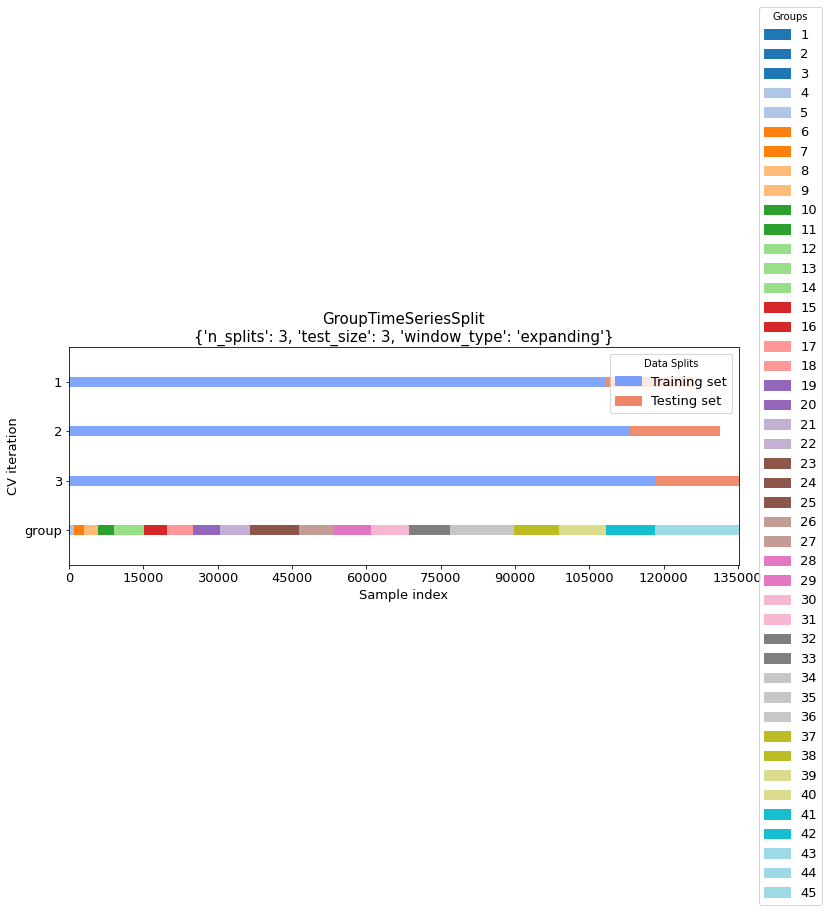

In [43]:
plot_splits(X_train, y_train, groups=groups, **cv_args)

In [44]:
res_table = pd.DataFrame(columns=['Модель', 'ROC_AUC', 'Approval_Rate',
                                  'Default_Rate', 'Missed_defaults_rate'])

In [45]:
def calculate_cv_metrics(FEATURE_COLS, TARGET_COL, model_name,
             pipeline, X_train, y_train, gtscv, groups, res_table):
    
    cv_metrics = {'Модель': [],'Fold_ID': [], 'ROC_AUC': [], "Approval_Rate" : [],
                  'Default_Rate': [], 'Missed_defaults_rate' : []}

    for i, (train_idx, val_idx) in enumerate(gtscv.split(X_train, y_train, groups=groups)):
        df_train_fold_base = df_train.iloc[train_idx].copy()
        df_val_fold_base = df_train.iloc[val_idx].copy()

        X_train_fold = df_train_fold_base[FEATURE_COLS]
        y_train_fold = df_train_fold_base[TARGET_COL]

        X_val_fold = df_val_fold_base[FEATURE_COLS]
        y_val_fold = df_val_fold_base[TARGET_COL]
        
        pipeline.fit(X_train_fold, y_train_fold)

        y_proba = pipeline.predict_proba(X_val_fold)[:, 1]
        y_pred = pipeline.predict(X_val_fold)

        tn, fp, fn, tp = confusion_matrix(y_val_fold, y_pred).ravel()

        auc = roc_auc_score(y_val_fold, y_proba)
        approval_rate = (tn + fn) / len(y_val_fold)
        default_rate = fn / (fn + tn)
        missed_defaults_rate = fn / (fn + tp)


        cv_metrics['Модель'].append(model_name)
        cv_metrics['Fold_ID'].append(f'Fold {i+1}')
        cv_metrics['ROC_AUC'].append(auc)
        cv_metrics['Approval_Rate'].append(approval_rate)
        cv_metrics['Default_Rate'].append(default_rate)
        cv_metrics['Missed_defaults_rate'].append(missed_defaults_rate)

    cv_results_df = pd.DataFrame(cv_metrics)
    print(model_name)
    print(cv_results_df)
    cv_results_df = cv_results_df.groupby('Модель')['ROC_AUC', 'Approval_Rate',
                                                    'Default_Rate', 'Missed_defaults_rate'].mean().reset_index()
    
    res_table = pd.concat([res_table, cv_results_df], ignore_index=True)
    
    return res_table

In [46]:
FEATURE_COLS = X_train.columns.tolist()
TARGET_COL = 'lag_1_target'

In [47]:
for model_name, pipeline in pipelines.items():
    res_table = calculate_cv_metrics(FEATURE_COLS=FEATURE_COLS, TARGET_COL=TARGET_COL,
                                     model_name=model_name, pipeline=pipeline, X_train=X_train,
                                     y_train=y_train, gtscv=gtscv, groups=groups, res_table=res_table)

logistic_regression_base
                     Модель Fold_ID   ROC_AUC  Approval_Rate  Default_Rate  \
0  logistic_regression_base  Fold 1  0.882831       0.962651      0.098178   
1  logistic_regression_base  Fold 2  0.885347       0.962741      0.097058   
2  logistic_regression_base  Fold 3  0.887914       0.962511      0.095730   

   Missed_defaults_rate  
0              0.814772  
1              0.815835  
2              0.816934  


/tmp/ipykernel_63/4058076515.py:40: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  cv_results_df = cv_results_df.groupby('Модель')['ROC_AUC', 'Approval_Rate',


logistic_regression_over_under
                           Модель Fold_ID   ROC_AUC  Approval_Rate  \
0  logistic_regression_over_under  Fold 1  0.882823       0.808768   
1  logistic_regression_over_under  Fold 2  0.885390       0.812459   
2  logistic_regression_over_under  Fold 3  0.887929       0.812040   

   Default_Rate  Missed_defaults_rate  
0      0.053215              0.371033  
1      0.052815              0.374641  
2      0.051093              0.367849  


/tmp/ipykernel_63/4058076515.py:40: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  cv_results_df = cv_results_df.groupby('Модель')['ROC_AUC', 'Approval_Rate',


logistic_regression_balanced
                         Модель Fold_ID   ROC_AUC  Approval_Rate  \
0  logistic_regression_balanced  Fold 1  0.882827       0.706158   
1  logistic_regression_balanced  Fold 2  0.885373       0.709226   
2  logistic_regression_balanced  Fold 3  0.887955       0.710543   

   Default_Rate  Missed_defaults_rate  
0      0.028720              0.174841  
1      0.027425              0.169822  
2      0.025154              0.158467  


...

/tmp/ipykernel_63/4058076515.py:40: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  cv_results_df = cv_results_df.groupby('Модель')['ROC_AUC', 'Approval_Rate',


rf_over_under
          Модель Fold_ID   ROC_AUC  Approval_Rate  Default_Rate  \
0  rf_over_under  Fold 1  0.932790       0.866131      0.048532   
1  rf_over_under  Fold 2  0.931850       0.869759      0.048126   
2  rf_over_under  Fold 3  0.934379       0.868370      0.046366   

   Missed_defaults_rate  
0              0.362377  
1              0.365462  
2              0.356979  


/tmp/ipykernel_63/4058076515.py:40: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  cv_results_df = cv_results_df.groupby('Модель')['ROC_AUC', 'Approval_Rate',


rf_balanced
        Модель Fold_ID   ROC_AUC  Approval_Rate  Default_Rate  \
0  rf_balanced  Fold 1  0.941433       0.958166      0.085575   
1  rf_balanced  Fold 2  0.939520       0.959719      0.087025   
2  rf_balanced  Fold 3  0.941545       0.953930      0.081236   

   Missed_defaults_rate  
0              0.706867  
1              0.729203  
2              0.687071  


/tmp/ipykernel_63/4058076515.py:40: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  cv_results_df = cv_results_df.groupby('Модель')['ROC_AUC', 'Approval_Rate',


In [48]:
res_table

,Модель,ROC_AUC,Approval_Rate,Default_Rate,Missed_defaults_rate
0,logistic_regression_base,0.885364,0.962634,0.096989,0.815847
1,logistic_regression_over_under,0.885381,0.811089,0.052374,0.371174
2,logistic_regression_balanced,0.885385,0.708642,0.027100,0.167710
3,rf_base,0.937016,0.949804,0.080557,0.668779
4,rf_over_under,0.933006,0.868087,0.047675,0.361606
5,rf_balanced,0.940833,0.957271,0.084612,0.707713


In [49]:
res_table_2 = pd.DataFrame(columns=['Модель', 'ROC_AUC', 'Approval_Rate',
                                  'Default_Rate', 'Missed_defaults_rate'])

В результате кросс валидации на тренировочных данных можно выделить 2 модели, демонстрирующих наилучшие результаты:
- <b>logistic_regression_balanced</b>
- <b>rf_over_under</b>

In [50]:
def objective(trial, X, y, groups, gtscv, model):
    
    params = {
        "model__n_estimators": trial.suggest_int("n_estimators", 50, 100),
        "model__max_depth": trial.suggest_int("max_depth", 10, 50),
        "model__max_features": trial.suggest_categorical("max_features", ['sqrt', 'log2', None]),
        "model__max_samples": trial.suggest_float("max_samples", 0.7, 1.0),
        "model__min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
    }
    
    model.set_params(**params)
    
    missed_default_scores = []
    for train_idx, val_idx in gtscv.split(X, y, groups=groups):
        X_train_fold = X.iloc[train_idx]
        y_train_fold = y.iloc[train_idx]
        X_val_fold = X.iloc[val_idx]
        y_val_fold = y.iloc[val_idx]
        
        model.fit(X_train_fold, y_train_fold)
        y_pred = model.predict(X_val_fold)
        
        missed_defaults_score = get_missed_defaults_rate(y_val_fold, y_pred)
        
        missed_default_scores.append(missed_defaults_score)
    
    return np.mean(missed_default_scores)

In [51]:
sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(lambda trial: objective(trial, X_train, y_train, groups, gtscv, model=pipelines['rf_over_under']), 
               n_trials=30, show_progress_bar=True)

best_params = study.best_params
print("Best params:", best_params)

best_rf = RandomForestClassifier(**best_params, random_state=RANDOM_SEED)

[I 2026-04-21 07:25:47,681] A new study created in memory with name: no-name-1d70d80b-fe81-4037-99ea-a1f7b1c1971e


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-21 07:26:36,278] Trial 0 finished with value: 0.345694486366775 and parameters: {'n_estimators': 69, 'max_depth': 48, 'max_features': 'sqrt', 'max_samples': 0.7467983561008608, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.345694486366775.
[I 2026-04-21 07:32:11,420] Trial 1 finished with value: 0.28120099870902315 and parameters: {'n_estimators': 94, 'max_depth': 34, 'max_features': None, 'max_samples': 0.9497327922401265, 'min_samples_leaf': 5}. Best is trial 1 with value: 0.28120099870902315.
[I 2026-04-21 07:32:46,582] Trial 2 finished with value: 0.3189111316108975 and parameters: {'n_estimators': 59, 'max_depth': 17, 'max_features': 'log2', 'max_samples': 0.7873687420594125, 'min_samples_leaf': 13}. Best is trial 1 with value: 0.28120099870902315.
[I 2026-04-21 07:35:29,584] Trial 3 finished with value: 0.2752795963927266 and parameters: {'n_estimators': 57, 'max_depth': 21, 'max_features': None, 'max_samples': 0.7599021346475079, 'min_samples_leaf': 11}. Best 

In [52]:
best_rf_pipe = pipelines['rf_over_under']
best_rf_pipe.set_params(model=best_rf)

res_table = calculate_cv_metrics(FEATURE_COLS=FEATURE_COLS, TARGET_COL=TARGET_COL,
                                     model_name='rf_over_under_optimized', pipeline=best_rf_pipe, X_train=X_train,
                                     y_train=y_train, gtscv=gtscv, groups=groups, res_table=res_table)

rf_over_under_optimized
                    Модель Fold_ID   ROC_AUC  Approval_Rate  Default_Rate  \
0  rf_over_under_optimized  Fold 1  0.943771       0.847992      0.036783   
1  rf_over_under_optimized  Fold 2  0.945169       0.853069      0.036281   
2  rf_over_under_optimized  Fold 3  0.945304       0.851013      0.034498   

   Missed_defaults_rate  
0              0.268898  
1              0.270224  
2              0.260297  


/tmp/ipykernel_63/4058076515.py:40: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  cv_results_df = cv_results_df.groupby('Модель')['ROC_AUC', 'Approval_Rate',


In [53]:
param_grid = [
    {
        'model__C': np.logspace(-3, 1, 10),
        'model__penalty': ['l1'],
        'model__solver': ['liblinear', 'saga']
    },
    {
        'model__C': np.logspace(-3, 1, 10),
        'model__penalty': ['l2'],
        'model__solver': ['lbfgs', 'liblinear', 'saga']
    }
]

best_lr = GridSearchCV(
    estimator=pipelines['logistic_regression_balanced'],
    param_grid=param_grid,
    cv=gtscv,
    scoring=missed_defaults_scorer,
    n_jobs=-1,
    verbose=1
)

best_lr.fit(X_train, y_train, groups=groups)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


GridSearchCV(cv=<mlxtend.evaluate.time_series.GroupTimeSeriesSplit object at 0x7f71d67dc700>,
             estimator=Pipeline(steps=[('prep',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['credit '
                                                                          'load',
                                                                          'MCC_5411',
                                                                          'учетная_ставка',
                                                                          'возраст',
                                                                          'aggravating_coef',
                                                                          'MCC_5722',
                                                                          'наличие_ипотеки',
                                                                          'уровень_безработицы',
                                                                          'MCC_5814',
                                                                          'income/spending',
                                                                          'MCC_другое',
                                                                          'сум...
                          'model__solver': ['liblinear', 'saga']},
                         {'model__C': array([1.00000000e-03, 2.78255940e-03, 7.74263683e-03, 2.15443469e-02,
       5.99484250e-02, 1.66810054e-01, 4.64158883e-01, 1.29154967e+00,
       3.59381366e+00, 1.00000000e+01]),
                          'model__penalty': ['l2'],
                          'model__solver': ['lbfgs', 'liblinear', 'saga']}],
             scoring=make_scorer(get_missed_defaults_rate, greater_is_better=False, response_method='predict'),
             verbose=1)

In [54]:
best_params = best_lr.best_params_

best_lr_model = LogisticRegression(
    random_state=RANDOM_SEED, 
    class_weight='balanced',
    C=best_params['model__C'],
    penalty=best_params['model__penalty'],
    solver=best_params['model__solver'])


best_lr_pipe = pipelines['logistic_regression_balanced']
best_lr_pipe.set_params(model=best_lr_model)

res_table = calculate_cv_metrics(FEATURE_COLS=FEATURE_COLS, TARGET_COL=TARGET_COL,
                                     model_name='logistic_regression_balanced_optimized', pipeline=best_lr_pipe, X_train=X_train,
                                     y_train=y_train, gtscv=gtscv, groups=groups, res_table=res_table)

logistic_regression_balanced_optimized
                                   Модель Fold_ID   ROC_AUC  Approval_Rate  \
0  logistic_regression_balanced_optimized  Fold 1  0.876792       0.672758   
1  logistic_regression_balanced_optimized  Fold 2  0.880739       0.676370   
2  logistic_regression_balanced_optimized  Fold 3  0.883066       0.680539   

   Default_Rate  Missed_defaults_rate  
0      0.025172              0.145990  
1      0.023511              0.138841  
2      0.022660              0.136728  


/tmp/ipykernel_63/4058076515.py:40: FutureWarning: Indexing with multiple keys (implicitly converted to a tuple of keys) will be deprecated, use a list instead.
  cv_results_df = cv_results_df.groupby('Модель')['ROC_AUC', 'Approval_Rate',


In [55]:
res_table

,Модель,ROC_AUC,Approval_Rate,Default_Rate,Missed_defaults_rate
0,logistic_regression_base,0.885364,0.962634,0.096989,0.815847
1,logistic_regression_over_under,0.885381,0.811089,0.052374,0.371174
2,logistic_regression_balanced,0.885385,0.708642,0.027100,0.167710
3,rf_base,0.937016,0.949804,0.080557,0.668779
4,rf_over_under,0.933006,0.868087,0.047675,0.361606
5,rf_balanced,0.940833,0.957271,0.084612,0.707713
6,rf_over_under_optimized,0.944748,0.850691,0.035854,0.266473
7,logistic_regression_balanced_optimized,0.880199,0.676556,0.023781,0.140519


В результате подбора гиперпараметров модели rf_over_under были улучшены все ключевые метрики (ROC_AUC: +1.72%, Default_Rate: -22.82%, Missed_defaults_rate: -22.83%) за исключением Approval_Rate, изменение которого незначительно снизилось.

В результате подбора гиперпараметров модели logistic_regression_balanced метрики ROC_AUC и Approval_Rate немного ухудшились, а метрики Default_Rate и Missed_defaults_rate немного улучшились, в целом, нельзя сказать, что подбор гиперпараметров значительно улучшил модель.

Модель случайного леса с овер и андерсэмлингом на кросс-валидации показывает наилучий ROC_AUC и достаточно хорошие значения по другим ключевым метрикам, она и будет использоваться в качестве финальной модели.

<a id='8'></a>
## Калибровка модели и пересчёт результатов

* Проведите калибровку лучшей версии модели. Используйте отдельную калибровочную выборку.
* Используйте метод, подходящий для случайного леса.
* Постройте график калибровки.
* Сделайте вывод, оцените результаты с помощью коэффициента Бриера.

In [56]:
# Обучаем модель на всех тренировочных данных
best_rf_pipe.fit(X_train, y_train)

Pipeline(steps=[('prep',
                 ColumnTransformer(transformers=[('categ',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore',
                                                                sparse_output=False),
                                                  ['семейное_положение']),
                                                 ('other', 'passthrough',
                                                  ['credit load', 'MCC_5411',
                                                   'учетная_ставка', 'возраст',
                                                   'aggravating_coef',
                                                   'MCC_5722',
                                                   'наличие_ипотеки',
                                                   'уровень_безработицы',
                                                   'MCC_5814',
                                                   'income/spending',
                                                   'MCC_другое',
                                                   'с...
                                                   'tranc_per_rating',
                                                   'кредитный_рейтинг',
                                                   'MCC_5812', 'MCC_5300',
                                                   'MCC_4900'])])),
                ('over',
                 RandomOverSampler(random_state=42, sampling_strategy=0.3)),
                ('under',
                 RandomUnderSampler(random_state=42, sampling_strategy=0.6)),
                ('model',
                 RandomForestClassifier(max_depth=19, max_features=None,
                                        max_samples=0.9995197586160781,
                                        min_samples_leaf=3, n_estimators=82,
                                        random_state=42))])

In [57]:
df_calib = df_calib.sort_values(by='score_date')

In [58]:
df_calib = df_calib.drop(columns=['score_date', 'ID'])
X_calib = df_calib.drop(columns='lag_1_target')
y_calib = df_calib['lag_1_target']

df_test = df_test.drop(columns=['score_date', 'ID'])
X_test = df_test.drop(columns='lag_1_target')
y_test = df_test['lag_1_target']

In [59]:
frozen_rf = FrozenEstimator(best_rf_pipe)
calibrated_rf_pipeline = CalibratedClassifierCV(
    frozen_rf, 
    method='isotonic',
    cv='prefit'
)

calibrated_rf_pipeline.fit(X_calib, y_calib)

y_prob_rf = best_rf_pipe.predict_proba(X_test)[:, 1]
y_prob_rf_calibrated = calibrated_rf_pipeline.predict_proba(X_test)[:, 1]

/opt/conda/lib/python3.9/site-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


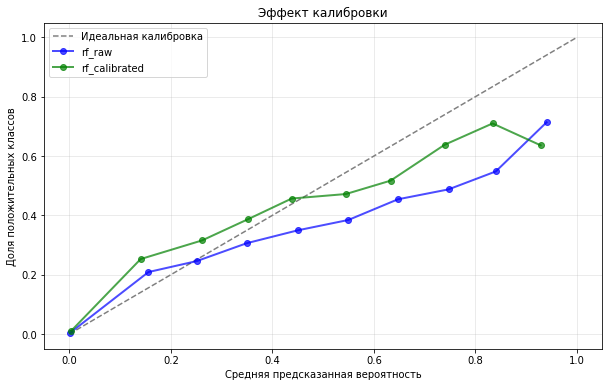

In [60]:
fop_orig_raw, mpv_orig_raw = calibration_curve(y_test, y_prob_rf, 
                                       n_bins=10)

fop_orig_calibrated, mpv_orig_calibrated = calibration_curve(y_test, y_prob_rf_calibrated, 
                                       n_bins=10)

# График
display_setup = ["blue", "green"]

plt.figure(figsize=(10, 6))
plt.plot([0, 1], [0, 1], '--', color='gray', label='Идеальная калибровка')

plt.plot(mpv_orig_raw, fop_orig_raw, marker='o', linewidth=2, 
         label="rf_raw", alpha=0.7, color=display_setup[0])

plt.plot(mpv_orig_calibrated, fop_orig_calibrated, marker='o', linewidth=2, 
         label="rf_calibrated", alpha=0.7, color=display_setup[1])

plt.xlabel('Средняя предсказанная вероятность')
plt.ylabel('Доля положительных классов')
plt.title('Эффект калибровки')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [61]:
brier_rf_uncal = brier_score_loss(y_test, y_prob_rf)
brier_rf_cal = brier_score_loss(y_test, y_prob_rf_calibrated)

print(f"Brier score (некалиброванная rf): {brier_rf_uncal:.4f}")
print(f"Brier score (калиброванная rf): {brier_rf_cal:.4f}")

Brier score (некалиброванная rf): 0.0719
Brier score (калиброванная rf): 0.0677


Модель RF изначально была неплохо откалибрована, но дополнительная калибровка улучшила результаты с 0.0719 до 0.0677

<a id='9'></a>
## Поиск порога решения

* Используя откалиброванную модель и калибровочную выборку, найдите порог, при котором будут достигнуты заданные в постановке задачи значения метрик:
    * approval rate — не менее 65%;
    * default rate — не более 2%;
    * missed defaults rate — не более 4%.
    
* Сделайте вывод о достигнутых в этом разделе результатах.

In [105]:
def find_threshold(y_proba, y_true, plot=True):
    thresholds = np.linspace(0, 1, 1001)

    approval_rates = []
    default_rates = []
    missed_default_rates = []

    for t in thresholds:
        approved = y_proba <= t
        n_approved = np.sum(approved)
        n_defaults_approved = np.sum(y_true[approved] == 1)
        n_total_defaults = np.sum(y_true == 1)

        approval_rate = n_approved / len(y_true)
        default_rate = n_defaults_approved / n_approved if n_approved > 0 else 0
        missed_default_rate = n_defaults_approved / n_total_defaults if n_total_defaults > 0 else 0

        approval_rates.append(approval_rate)
        default_rates.append(default_rate)
        missed_default_rates.append(missed_default_rate)

    valid_thresholds = []
    for t, ar, dr, mdr in zip(thresholds, approval_rates, default_rates, missed_default_rates):
        if ar >= 0.65 and dr <= 0.02 and mdr <= 0.04:
            valid_thresholds.append((t, ar, dr, mdr))

    if valid_thresholds:
        best_t, best_ar, best_dr, best_mdr = max(valid_thresholds, key=lambda x: x[1])
        print(f"Найден порог: {best_t:.3f}")
        print(f"Approval Rate: {best_ar:.3f}")
        print(f"Default Rate: {best_dr:.4f}")
        print(f"Missed Defaults Rate: {best_mdr:.4f}")
    else:
        print("Нет решения")
        best_t = None
        best_ar = None

    # графики
    if plot:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))

        axes[0].plot(thresholds, approval_rates, label='Approval Rate', color='blue')
        axes[0].axhline(y=0.65, color='gray', linestyle='--', label='Min AR = 0.65')
        axes[0].set_xlabel('Threshold')
        axes[0].set_ylabel('Approval Rate')
        axes[0].set_title('Approval Rate')
        axes[0].grid(True, alpha=0.3)
        axes[0].legend()

        axes[1].plot(thresholds, default_rates, label='Default Rate', color='red')
        axes[1].axhline(y=0.02, color='gray', linestyle='--', label='Max DR = 0.02')
        axes[1].set_xlabel('Threshold')
        axes[1].set_ylabel('Default Rate')
        axes[1].set_title('Default Rate')
        axes[1].grid(True, alpha=0.3)
        axes[1].legend()

        axes[2].plot(thresholds, missed_default_rates, label='Missed Default Rate', color='green')
        axes[2].axhline(y=0.04, color='gray', linestyle='--', label='Max MDR = 0.04')
        axes[2].set_xlabel('Threshold')
        axes[2].set_ylabel('Missed Default Rate')
        axes[2].set_title('Missed Default Rate')
        axes[2].grid(True, alpha=0.3)
        axes[2].legend()

        if valid_thresholds:
            valid_t_vals = [v[0] for v in valid_thresholds]
            t_min, t_max = min(valid_t_vals), max(valid_t_vals)
            for ax in axes:
                ax.axvspan(t_min, t_max, alpha=0.2, color='green', label='Допустимая зона')
            if best_t is not None:
                axes[0].axvline(x=best_t, color='black', linestyle='-', label=f'Best t={best_t:.3f}')
                axes[1].axvline(x=best_t, color='black', linestyle='-', label=f'Best t={best_t:.3f}')
                axes[2].axvline(x=best_t, color='black', linestyle='-', label=f'Best t={best_t:.3f}')
                axes[0].scatter(best_t, best_ar, color='black', zorder=5)
                axes[1].scatter(best_t, best_dr, color='black', zorder=5)
                axes[2].scatter(best_t, best_mdr, color='black', zorder=5)
            for ax in axes:
                ax.legend()

        plt.tight_layout()
        plt.show()

    return best_t

Порог для случайного леса
Найден порог: 0.086
Approval Rate: 0.706
Default Rate: 0.0050
Missed Defaults Rate: 0.0352


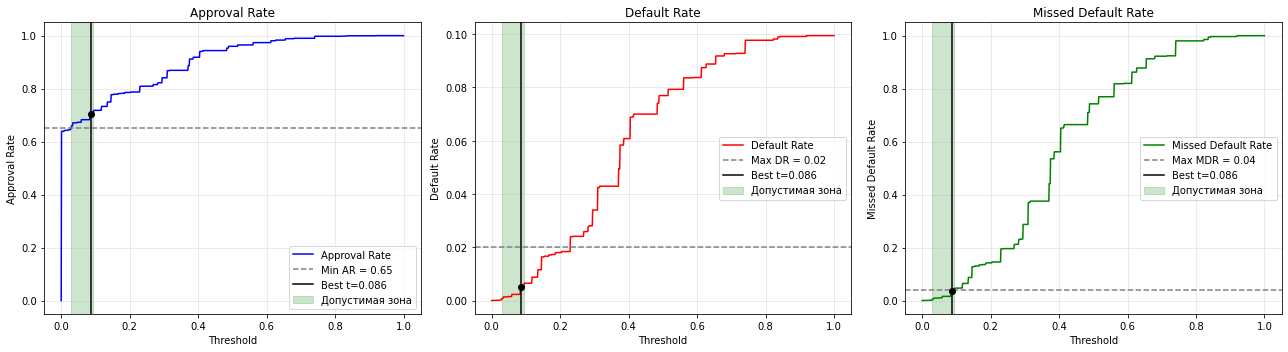

In [106]:
y_proba_rf_calib = calibrated_rf_pipeline.predict_proba(X_calib)[:, 1]

print('Порог для случайного леса')
t_rf = find_threshold(y_proba_rf_calib, y_calib)

Полученное значение порога 0.086 является достаточно строгим значением, иными словами, если модель считает, что вероятность дефолта клиента выше 8.6%, то в выдаче кредита ему отказываем.

При таком низком пороге Approval Rate стал более низким - теперь модель одобрит только самых надежных заемщиков, Default Rate стало крайне низким — среди одобренных кредитов почти нет дефолтов, Missed Default Rate также стало низким - клиентов с дефолтом пропущено очень мало из-за "сурового" отбора. Другими словами модель стала более консервативной в вопросе выдачи кредитов

<a id='10'></a>
## Анализ матрицы ошибок

* Оцените стабильность модели на тестовых данных. Для этого постройте:
    * матрицу ошибок на калибровочных данных;
    * матрицу классификации на тестовых данных.
* Сделайте вывод о моделях, рассчитав классические метрики машинного обучения и указанные в ТЗ бизнес-метрики.
* Сделайте вывод о стабильности модели.

In [107]:
def get_metrics(proba_test, y_test, t):
    approved_test = proba_test <= t

    n_approved_test = np.sum(approved_test)
    n_defaults_approved_test = np.sum(y_test[approved_test] == 1)
    n_total_defaults_test = np.sum(y_test == 1)

    auc = roc_auc_score(y_test, proba_test)
    approval_rate_test = n_approved_test / len(y_test)
    default_rate_test = n_defaults_approved_test / n_approved_test if n_approved_test > 0 else 0
    missed_default_rate_test = n_defaults_approved_test / n_total_defaults_test if n_total_defaults_test > 0 else 0

    print(f"Тестовый ROC_AUC: {auc:.2f}")
    print(f"Тестовый Approval Rate: {approval_rate_test*100:.2f}%")
    print(f"Тестовый Default Rate: {default_rate_test*100:.2f}%")
    print(f"Тестовый Missed Defaults Rate: {missed_default_rate_test*100:.2f}%")

In [112]:
y_proba_rf_test = calibrated_rf_pipeline.predict_proba(X_test)[:, 1]

print(f'Метрики для случайного леса с порогом: {t_rf:.4f}')
get_metrics(y_proba_rf_test, y_test, t_rf)

Метрики для случайного леса с порогом: 0.0860
Тестовый ROC_AUC: 0.92
Тестовый Approval Rate: 72.80%
Тестовый Default Rate: 0.86%
Тестовый Missed Defaults Rate: 5.91%


ROC-AUC = 0.92 : модель отлично ранжирует клиентов по вероятности дефолта 


Approval Rate = 72.8% : модель выдаёт кредиты 72.8% клиентов. Это выше минимального требования 65%


Default Rate = 0.86% : среди тех, кому модель выдала кредит, только 0.86% оказываются дефолтниками. Это ниже лимита в 2%


Missed Default Rate = 5.91% : из всех реальных дефолтников в тестовой выборке модель ошибочно одобрила 5.91%. Требование по Missed Default Rate не больше 4% не выполнено

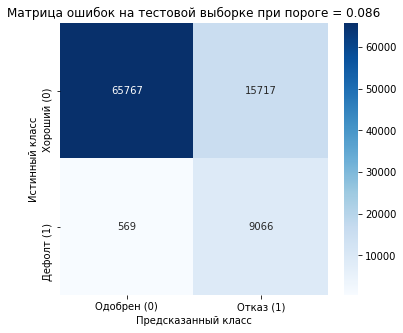

In [109]:
y_pred_test = (y_proba_rf_test > t_rf).astype(int)
cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Одобрен (0)', 'Отказ (1)'],
            yticklabels=['Хороший (0)', 'Дефолт (1)'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title(f'Матрица ошибок на тестовой выборке при пороге = {t_rf:.3f}')
plt.show()

Матрица ошибок RF на тестовой выборке:
  * модель достаточно хорошо отличает клиентов, у которых действительно случится дефолт: модель отказала в кредите 9060 клиентам из 9635 (94.1%) и ошибочно одобрила кредит 569 (5.9%) клиентам у которых произошел дефолт
  * Модель достаточно часто отказывает платежеспособным клиентам в кредите - 15717 случая из 81484, т.е. 19.3% отказов оказались ошибочны

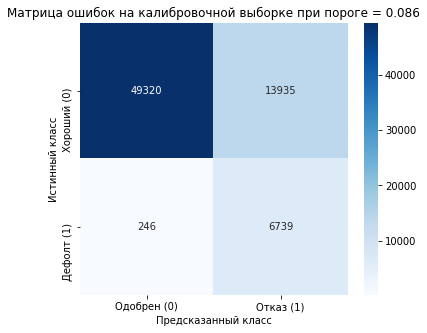

In [111]:
y_pred_calib = (y_proba_rf_calib > t_rf).astype(int)
cm = confusion_matrix(y_calib, y_pred_calib)
tn, fp, fn, tp = cm.ravel()

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Одобрен (0)', 'Отказ (1)'],
            yticklabels=['Хороший (0)', 'Дефолт (1)'])
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title(f'Матрица ошибок на калибровочной выборке при пороге = {t_rf:.3f}')
plt.show()

Матрица RF на калибровочной выборке:
  * модель достаточно хорошо отличает клиентов, у которых действительно случится дефолт: модель отказала в кредите 6739 клиентам из 6985 (96.5%) и ошибочно одобрила кредит 246 (3,5%) клиентам у которых произошел дефолт
  * Модель достаточно часто отказывает платежеспособным клиентам в кредите - 13935 случая из 63255, т.е. 22% отказов оказались ошибочны

<a id='11'></a>
## Фиксирование итоговой модели

- Опишите лучшую модель и найденный порог классификации.


    - Наилучшей моделью с точки зрения стабильности и метрик оказалась модель случайного леса с овер и андерсэмлингом
    - Не все метрики на тестовой выборке с порогом классификации 0.086 удовлетворяют тербованиям заказчика:
      * ROC_AUC: 0.92
      * Approval Rate: 72.80% : больше 65% - требование выполнено
      * Default Rate: 0.86% : меньше 2% - требование выполнено
      * Missed Defaults Rate: 5.91% : не больше 4% - требование НЕ выполнено
      
Из матрицы ошибок модели на тестовой и калибровочной выборках видно, что метрики на разных выборках не являются достаточно стабильными, например, Missed Defaults Rate на тестовой выборке 5.9% (не удовлетворят требованиям), а на калибровочной выборке 3.5% (удовлетворяет условиям). Подобную проблему скорее всего можно решить небольшим снижением порога, что повлечет за собой и снижение Approval Rate, однако в этой метрике еще есть "запас" для снижения, при которой она будет удовлетворять требованиям заказчика.

<a id='12'></a>
## Анализ важности признаков

* Проведите анализ важности признаков найденной модели на полных тренировочных данных.
* Используйте `feature_importances_` для найденной модели.
* Сделайте вывод о силе влияния признаков на дефолт.

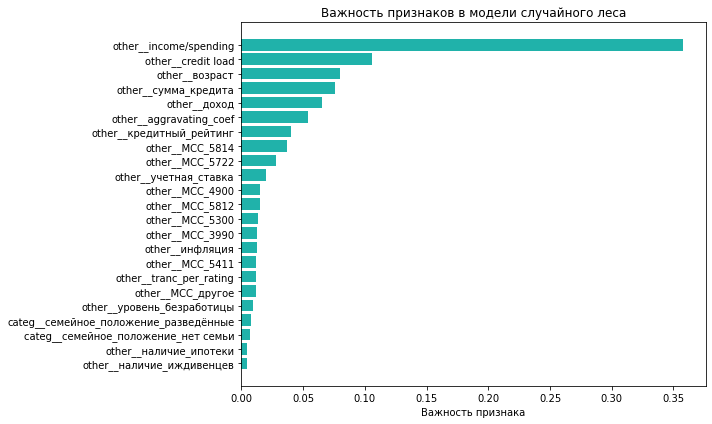

In [113]:
feature_importance = pd.DataFrame({
    "feature": calibrated_rf_pipeline.calibrated_classifiers_[0].estimator.named_steps["prep"].get_feature_names_out(),
    "importance": calibrated_rf_pipeline.calibrated_classifiers_[0].estimator.named_steps["model"].feature_importances_
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(
    y=feature_importance["feature"][::-1],
    width=feature_importance["importance"][::-1],
    color='lightseagreen'
)
plt.xlabel("Важность признака")
plt.title("Важность признаков в модели случайного леса")
plt.tight_layout()
plt.show()

Наиболее важными признаками для модели логистической регрессии оказались:
  * income/spending : 0.358099
  * credit load : 0.105785
  * возраст : 0.079612
  * сумма_кредита : 0.076102
  * доход : 0.065424

<a id='13'></a>
## Выводы по проекту

Сделайте выводы по проекту. Можете использовать такой план:

1. Цель и задачи исследования.

2. Подготовка данных и выборок.

3. Поиск и настройка модели.

4. Калибровка вероятностей.

5. Оптимизация бизнес-порога.

6. Анализ важности признаков.

7. Финальный пайплайн.

8. Основные выводы и рекомендации для бизнеса.



    В результате реализации проекта была создана модель машинного обучения для предсказания вертоятности того, что клиент банка совершит просрочку платежа по кредиту длительностью от 90 дней в течение ближайших 12 месяцев
    
    В процессе подготовки данных было выгруженно 8 таблиц с данными о 13500 клиентах с данными помесячно с начала 2013 г. до конца 2019 г., общее количество записей составило 577_494, также среди таблиц были выгружены экономические макропоказатели за аналогичный период
    
    В результате объединения таблиц, формирования целевой переменной и удаления пустых значений количество строк в датафрейме сократилось до 307_963, что является достаточным для построения модели
    
    Были созданы 4 новых признака на основании существующих:
      - Сумма транзакций, приходящаяся на единицу рейтинга
      - Признак, учитывающий 'отягчающие' для платы факторы
      - Отношение доходов к тратам
      - Отношение суммы кредита к доходам
      
    Данные были разделены на три выборки:
      - Тренировочная выборка: 2013-03-01 - 2016-11-01 | Строк: 135169
      - Калибровочная выборка: 2016-12-01 - 2017-11-01 | Строк: 70240
      - Тестовая выборка:  2017-12-01 - 2018-12-01 | Строк: 91119
      
    В результате кросс валидации на тренировочных данных выделили 2 модели, демонстрирующих наилучшие результаты:
      - Логистическая регрессия с балансировкой через встроенный в sklearn параметр class_weight='balanced'
      - Случайный лес с комбинацией оверсэмлинга и андерсэмплинга
      
    Для выбранных моделей были подобраны оптимальные гиперпараметры. В качестве финальной модели была выбрана модель случайного леса с комбинацией оверсэмлинга и андерсэмплинга которая была откалибрована с помощью изотонической регрессии. В результате калибровки оценка Бриера для модели снизилась с 0.0719 до 0.0677
    
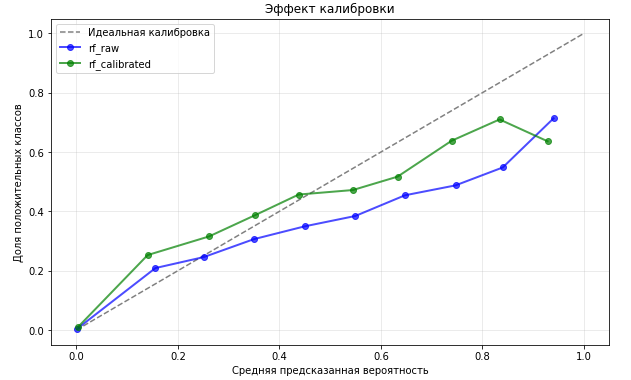

    Порог, удовлетворяющий условиям:
        - Approval rate не менее 65%
        - Default rate не более 2%
        - Missed defaults rate не более 4%
    составил 0.086
      
    В результате тестирования модели на тестовой выборке были получены следующие метрики:
        Для случайного леса (с порогом классификации 0.086):
          - Тестовый ROC_AUC: 0.92
          - Тестовый Approval Rate: 72.80% : больше 65% - требование выполнено
          - Тестовый Default Rate: 0.86% : меньше 2% - требование выполнено
          - Тестовый Missed Defaults Rate: 5.91% : не больше 4% - требование НЕ выполнено
          
    Наиболее важными признаками для модели логистической регрессии оказались:
      - income/spending : 0.358099
      - credit load : 0.105785
      - возраст : 0.079612
      - сумма_кредита : 0.076102
      - доход : 0.065424
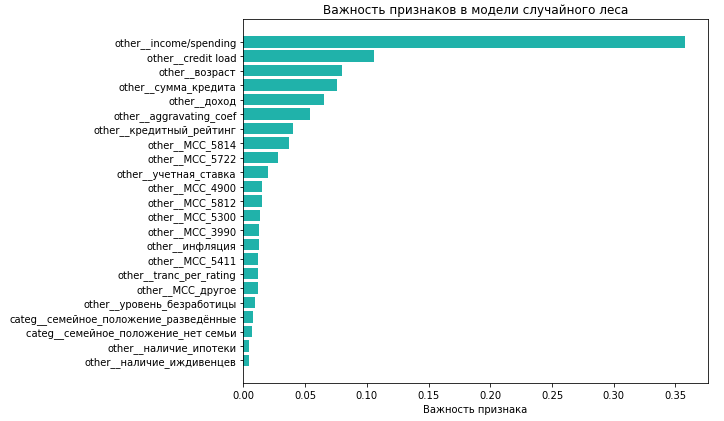
      
    В результате анализа матрицы ошибок на тестовой и калбировочной выборках подтверждает что модель в 94.1-96.5% случаев обнаруживает дефолтных клиентов и отказывает им в выдаче кредитов.
    
    Текущая проблемой модели является высокая волатильность метрики Missed Defaults Rate на разных выборках, например, на тестовой выборке 5.9% (не удовлетворят требованиям), а на калибровочной выборке 3.5% (удовлетворяет условиям). Подобную проблему скорее всего можно решить небольшим снижением порога, что повлечет за собой и снижение Approval Rate, однако в этой метрике еще есть "запас" для снижения, при которой она будет удовлетворять требованиям заказчика.